# Convert PyTorch weights to Flax and locate numerical errors

Runnable locally on CPU or on a Cloud TPU VM.

- Map named PyTorch tensors into Flax NNX parameters with complete key, shape and dtype checks.
- Locate the first mismatching operation using absolute and relative errors.
- Verify input gradients and reload the converted artifact independently.

You copied a checkpoint and the new model runs, but its answers differ. Is the weight mapping wrong, or does the architecture compute a different function? We will load actual PyTorch tensors into a Flax NNX model and stop at the first layer whose values diverge.

## The idea

When a converted model disagrees with its reference, compare aligned intermediate activations on identical inputs. The earliest divergent boundary usually gives a more useful diagnosis than the final output alone.

## Find the earliest disagreement

Suppose the first dense output agrees but normalized activations do not. Inspect the normalization axis, epsilon and parameter mapping before changing the final layer. A later output difference may only be a consequence of the earlier mismatch.

Record absolute error and an appropriate relative measure. Near-zero references can make relative error large even when absolute error is small, so tolerances need scale and dtype context.

The layer-error plot identifies a location to investigate, not a universal threshold for all architectures. Use several inputs, including boundary cases, and compare the full preprocessing-to-output contract. Matching one fixture is separate from arbitrary checkpoint compatibility.

### Small errors need a scale-aware budget

**Predict:** Why can a larger absolute difference pass at a larger reference value?

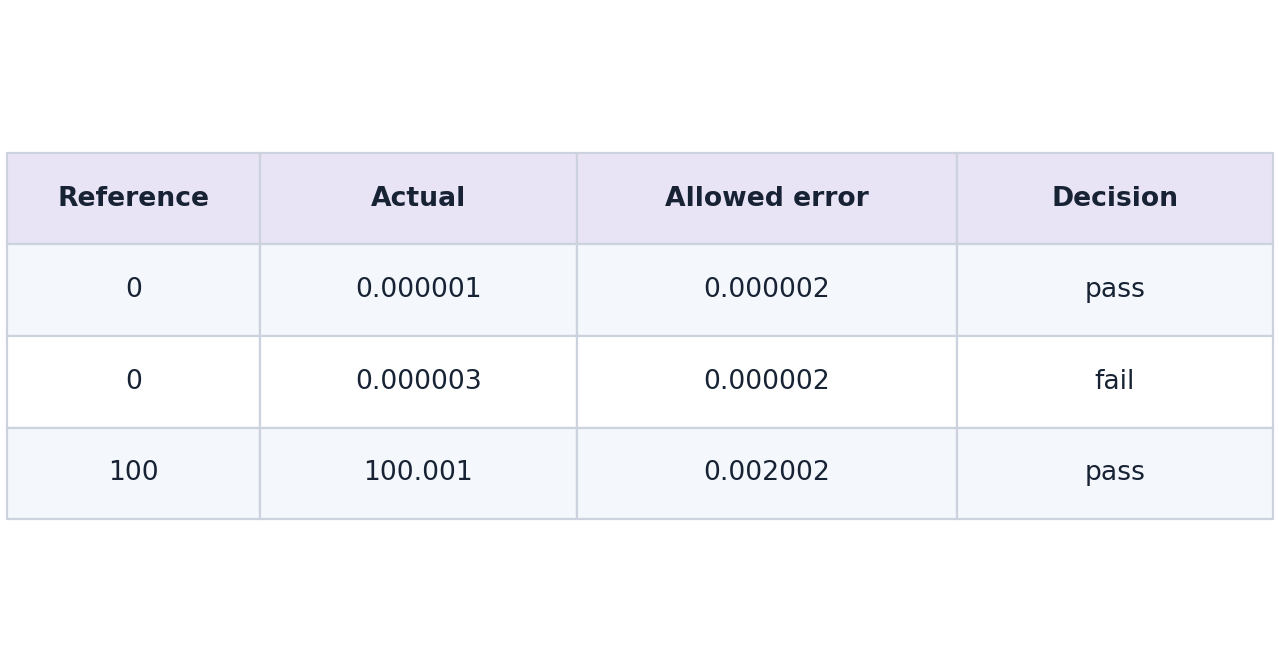

*Architecture and dataflow mechanism diagram.*

Read each row as one elementwise decision using absolute tolerance $2\times10^{-6}$ and relative tolerance $2\times10^{-5}$. Near zero the absolute term determines the allowance. At reference $100$, the relative term increases it. These are hand-worked tolerance examples, not measured conversion errors; the executed bar plot below reports the model comparison.

### Pause and reason

Why can only comparing final probabilities hide useful information?

<details><summary>Compare your reasoning</summary>

Different intermediate errors can cancel or be compressed by the final nonlinearity. Layerwise comparisons locate where the intended computation first changed.

</details>

## Write the architecture contract before mapping weights

Our input has shape $(B,3)$, the hidden width is $5$, and the output width is $2$. PyTorch Linear stores output-by-input weights, while Flax Linear uses input-by-output kernels, so transpose those two arrays. LayerNorm scale and bias stay one-dimensional and do not transpose. Require every expected key exactly once; ignoring unknown or missing parameters can silently leave random weights in the target.

## Match operations, not just tensors

Use the same LayerNorm epsilon, feature axes, variance convention and affine parameters. Select exact GELU in both frameworks instead of mixing exact and tanh approximations. Disable training-only behavior and match preprocessing, padding, positions and output labels before claiming parity. The Flax implementation disables the fast variance formula to make the comparison boundary explicit; float32 execution can still differ slightly across kernels.

## Use an error budget that works near zero

For each element, require the absolute difference to fit an absolute tolerance plus a relative tolerance times the reference magnitude. Absolute tolerance handles near-zero references; relative tolerance scales with large values. Report maximum absolute error and relative L2 error, but retain the elementwise decision so a small aggregate cannot hide a bad element. Set tolerances before inspecting the candidate, record dtype/backend, and never turn NaN into a passing comparison.

$$
|y_i-\widehat y_i|\leq a+r|y_i|,\qquad e_{\mathrm{rel},2}=\frac{\|y-\widehat y\|_2}{\max(\|y\|_2,10^{-12})}
$$

## Find the first mismatch

Capture hidden linear output, normalized values, activation and final logits for the same inputs. A wrong LayerNorm epsilon leaves the hidden linear output correct but changes the normalized output first. Later mismatches may be consequences rather than separate bugs. Use several batch sizes and amplitudes: one large random batch can miss epsilon-sensitive or near-zero behavior.

## Validate the derivative and the saved artifact

For a scalar sum of outputs, compare gradients with respect to the input in both frameworks. Then save the Flax arrays with architecture metadata and reload them before inference. The project also starts a fresh process for this step. Only load trusted checkpoint sources; weights_only loading limits the PyTorch loading path but is separate from authenticity or universal safety.

## Extend the mapping deliberately

Convolution kernels may require OIHW to HWIO permutations, not a dense transpose. Attention may fuse query/key/value tensors or arrange heads differently. Tied embeddings, normalization order, rotary positions and vocabulary row order can all change behavior despite matching shapes. Add these operations one at a time with golden inputs and intermediate comparisons. This lesson validates its named MLP only; those additional architectures need their own executed mappings.

## Read an error budget one element at a time

A relative error alone behaves badly near a zero reference. Use an absolute allowance $a$ near zero and a relative allowance $r$ for larger values. For a reference $y$ and converted value $\hat y$, the allowed difference is $a+r|y|$. The reference is deliberately the source value; exchanging the two arguments changes the budget slightly.

With $a=2\times10^{-6}$ and $r=2\times10^{-5}$, a reference of zero allows $2\times10^{-6}$ absolute error. An error of $10^{-6}$ passes even though dividing by the reference is undefined. At reference $100$, the budget is $0.002002$, so an error of $0.001$ passes. These tolerances are declared checks for this FP32 fixture. Derive and test a different budget for a different computation or precision policy.

$$
|\hat y_i-y_i|\leq a+r|y_i|
$$

### Pause and reason

An output near zero differs by $3\times10^{-6}$. Does a small relative-L2 error over the whole tensor guarantee it passes?

<details><summary>Compare your reasoning</summary>

No. The per-element absolute allowance near zero is about $2\times10^{-6}$. A global norm can conceal one failing element among many large, accurate values. Keep the elementwise gate as well as summary metrics.

</details>

## Probe more than the sum of the outputs

The companion compares the input gradient of the sum of outputs. That is one projection of the Jacobian: it weights every output equally. Opposing errors can cancel in that projection. Use a nonuniform output sensitivity, called a cotangent, to ask how a different weighted combination changes with the input.

Keep the source in evaluation mode, use the same input and cotangent, and reset the PyTorch input gradient before comparing. Inspect the first failing forward boundary before studying derivative differences. Matching this additional probe strengthens the test; it still does not prove equality of the entire Jacobian for every input.

$$
J(x)^{\mathsf T}v=\nabla_x\left(\sum_i v_i f_i(x)\right)
$$

## Make the source boundaries inspectable

Create main.py in your lesson workspace and run it with the active course Python environment. Define the source model so every named operation returns its intermediate result.

In [1]:
# Step 1: Make the source boundaries inspectable
"""Explicit CPU PyTorch -> Flax NNX mapping; no generic architecture converter."""
# Import numpy for this computation.
import numpy as np
import jax
import jax.numpy as jnp
import torch
from flax import nnx

# Define `TorchModel` module / container with explicit state and forward pass:
class TorchModel(torch.nn.Module):
    # Function `__init__(self, eps)` implementing this stage's computation:
    def __init__(self, eps=1e-5):
        # Run `super` to perform the next check or state transition.
        super().__init__()
        # Run `torch.nn.Linear` to compute `self.hidden`.
        self.hidden=torch.nn.Linear(3,5)
        # Run `torch.nn.LayerNorm` to compute `self.norm`.
        self.norm=torch.nn.LayerNorm(5,eps=eps)
        # Run `torch.nn.Linear` to compute `self.out`.
        self.out=torch.nn.Linear(5,2)
    # Function `forward(self, x)` implementing this stage's computation:
    def forward(self,x):
        # Run `self.hidden` to compute `h`.
        # Run `self.norm` to compute `n`.
        # Run `torch.nn.functional.gelu` to compute `a`.
        h=self.hidden(x)
        n=self.norm(h)
        a=torch.nn.functional.gelu(n,approximate='none')
        # Return `{'hidden': h, 'norm': n, 'activation': a, 'output': self.out(a)}` to the caller.
        return {'hidden':h,'norm':n,'activation':a,'output':self.out(a)}

# Assert invariant `TorchModel().eval()(torch.zeros((2` holds
assert TorchModel().eval()(torch.zeros((2,3)))['output'].shape == (2,2)

The probe has two observations and returns an output of shape $(2,2)$. It also exposes hidden, normalization and activation tensors for diagnosis.

## Write the same operations in Flax

Append this block to the same main.py and rerun the whole file. Match dimensions, normalization epsilon, variance calculation and exact GELU.

In [2]:
# Step 2 — Write the same operations in Flax: The probe again returns shape (2,2).
# Define `FlaxModel` module / container with explicit state and forward pass:
class FlaxModel(nnx.Module):
    # Function `__init__(self, eps)` implementing this stage's computation:
    def __init__(self,eps=1e-5):
        # Run `nnx.Linear` to compute `self.hidden`.
        self.hidden=nnx.Linear(3,5,rngs=nnx.Rngs(0))
        # Run `nnx.LayerNorm` to compute `self.norm`.
        self.norm=nnx.LayerNorm(5,epsilon=eps,use_fast_variance=False,rngs=nnx.Rngs(1))
        # Run `nnx.Linear` to compute `self.out`.
        self.out=nnx.Linear(5,2,rngs=nnx.Rngs(2))
    # Function `__call__(self, x)` implementing this stage's computation:
    def __call__(self,x):
        # Run `self.hidden` to compute `h`.
        # Run `self.norm` to compute `n`.
        # Apply nonlinear activation or probability normalization to compute `a`.
        h=self.hidden(x)
        n=self.norm(h)
        a=jax.nn.gelu(n,approximate=False)
        # Return `{'hidden': h, 'norm': n, 'activation': a, 'output': self.out(a)}` to the caller.
        return {'hidden':h,'norm':n,'activation':a,'output':self.out(a)}

# Assert invariant `FlaxModel()(jnp.zeros((2` holds
assert FlaxModel()(jnp.zeros((2,3)))['output'].shape == (2,2)

The probe again returns shape $(2,2)$. At this point random parameters differ; matching shapes does not mean matching predictions.

## Map each parameter and declare tolerances

Append this block to the same main.py and rerun the whole file. Copy checked source arrays into named destination parameters. Compare a hidden output with an independent matrix calculation.

In [3]:
# Step 3 — Map each parameter and declare tolerances: The hidden-layer check passes after transposing the source kernel.
def convert(state,eps=1e-5):
    # Compute `shapes` from `{'hidden.weight':(5,3),'hidden.bias':(5,),'norm.weig...`
    shapes={'hidden.weight':(5,3),'hidden.bias':(5,),'norm.weight':(5,),'norm.bias':(5,),'out.weight':(2,5),'out.bias':(2,)}
    # Guard input contract (`set(state) != set(shapes)`) and fail fast if violated.
    if set(state)!=set(shapes):raise ValueError('missing or unexpected state key')
    # Compute `arrays` from `{}`
    arrays={}
    # Iterate over `(name, shape)` to step through the computation:
    for name,shape in shapes.items():
        # Compute `value` from `state[name].detach().cpu().numpy()`
        value=state[name].detach().cpu().numpy()
        # Guard input contract (`value.shape != shape or value.dtype != np.float32 or (not np.isfinite(value).all())`) and fail fast if violated.
        if value.shape!=shape or value.dtype!=np.float32 or not np.isfinite(value).all():
            raise ValueError('unexpected shape, dtype or nonfinite tensor: '+name)
        # Run `value.copy` to compute `arrays[name]`.
        arrays[name]=value.copy()
    # Run `FlaxModel` to compute `target`.
    target=FlaxModel(eps)
    # Create device-backed JAX array `target.hidden.kernel[...]`.
    target.hidden.kernel[...]=jnp.asarray(arrays['hidden.weight'].T)
    # Create device-backed JAX array `target.hidden.bias[...]`.
    target.hidden.bias[...]=jnp.asarray(arrays['hidden.bias'])
    # Create device-backed JAX array `target.norm.scale[...]`.
    target.norm.scale[...]=jnp.asarray(arrays['norm.weight'])
    # Create device-backed JAX array `target.norm.bias[...]`.
    target.norm.bias[...]=jnp.asarray(arrays['norm.bias'])
    # Create device-backed JAX array `target.out.kernel[...]`.
    target.out.kernel[...]=jnp.asarray(arrays['out.weight'].T)
    # Create device-backed JAX array `target.out.bias[...]`.
    target.out.bias[...]=jnp.asarray(arrays['out.bias'])
    # Return `target` to the caller.
    return target

# Function `error_report(reference, actual, atol, rtol)` implementing this stage's computation:
def error_report(reference,actual,atol=2e-6,rtol=2e-5):
    # Convert `reference` to a host NumPy array for inspection or verification.
    # Convert `actual` to a host NumPy array for inspection or verification.
    reference=np.asarray(reference,dtype=np.float64)
    actual=np.asarray(actual,dtype=np.float64)
    # Guard input contract (`reference.shape != actual.shape or not np.isfinite(reference).all() or (not np.isfinite(actual).all())`) and fail fast if violated.
    if reference.shape!=actual.shape or not np.isfinite(reference).all() or not np.isfinite(actual).all():
        raise ValueError('shape or finite-value mismatch')
    # Guard input contract (`min(atol, rtol) < 0 or not np.isfinite([atol, rtol]).all()`) and fail fast if violated.
    if min(atol,rtol)<0 or not np.isfinite([atol,rtol]).all():raise ValueError('invalid tolerances')
    # Run `np.abs` to compute `absolute`.
    absolute=np.abs(actual-reference)
    # Compute `budget` from `atol+rtol*np.abs(reference)`
    budget=atol+rtol*np.abs(reference)
    # Return `{'max_abs': float(absolute.max()), 'relative_l2': float(np.linalg.norm(actual - reference) / max(np.linalg.norm(reference), 1e-12)), 'passed': bool(np.all(absolute <= budget))}` to the caller.
    return {'max_abs':float(absolute.max()),'relative_l2':float(np.linalg.norm(actual-reference)/max(np.linalg.norm(reference),1e-12)),
            'passed':bool(np.all(absolute<=budget))}

# Run `TorchModel` to compute `step_source`.
step_source = TorchModel().eval()
# Run `convert` to compute `step_target`.
step_target = convert(step_source.state_dict())
# Compute `step_input` from `np.array([[1., -2., .5]], np.float32)`
step_input = np.array([[1., -2., .5]], np.float32)
# Perform matrix contraction / projection to compute `step_expected`.
step_expected = step_input @ step_source.hidden.weight.detach().numpy().T + step_source.hidden.bias.detach().numpy()
# Create device-backed JAX array ``.
np.testing.assert_allclose(step_target(jnp.asarray(step_input))['hidden'], step_expected, rtol=2e-5, atol=2e-6)

The hidden-layer check passes after transposing the source kernel. A missing key or wrong source shape should fail before inference.

## Save and reload the converted state

Append this block to the same main.py and rerun the whole file. Store architecture metadata with the arrays and rebuild the target from that archive.

In [4]:
# Step 4 — Save and reload the converted state: The temporary round trip preserves a probe output.
def save_flax(model,path):
    # Convert `` to a host NumPy array for inspection or verification.
    np.savez(path,hidden_kernel=np.asarray(model.hidden.kernel[...]),hidden_bias=np.asarray(model.hidden.bias[...]),
             norm_scale=np.asarray(model.norm.scale[...]),norm_bias=np.asarray(model.norm.bias[...]),
             out_kernel=np.asarray(model.out.kernel[...]),out_bias=np.asarray(model.out.bias[...]),
             epsilon=np.array(model.norm.epsilon),schema=np.array(1))

# Function `load_flax(path)` implementing this stage's computation:
def load_flax(path):
    # Compute `shapes` from `{'hidden_kernel':(3,5),'hidden_bias':(5,),'norm_scal...`
    shapes={'hidden_kernel':(3,5),'hidden_bias':(5,),'norm_scale':(5,),'norm_bias':(5,),'out_kernel':(5,2),'out_bias':(2,)}
    # Enter `np.load(path, allow_pickle=False)` context block:
    with np.load(path,allow_pickle=False) as archive:
        # Guard input contract (`set(archive.files) != set(shapes) | {'epsilon', 'schema'}`) and fail fast if violated.
        if set(archive.files)!=set(shapes)|{'epsilon','schema'}:raise ValueError('unexpected archive schema')
        # Guard input contract (`archive['schema'].shape != () or int(archive['schema']) != 1`) and fail fast if violated.
        if archive['schema'].shape!=() or int(archive['schema'])!=1:raise ValueError('unknown schema')
        # Guard input contract (`archive['epsilon'].shape != ()`) and fail fast if violated.
        if archive['epsilon'].shape!=():raise ValueError('epsilon must be scalar')
        # Evaluate `archive['epsilon']` and convert the result into Python scalar/collection `eps`.
        eps=float(archive['epsilon'])
        # Guard input contract (`not np.isfinite(eps) or eps <= 0`) and fail fast if violated.
        if not np.isfinite(eps) or eps<=0:raise ValueError('invalid epsilon')
        # Compute `arrays` from `{}`
        arrays={}
        # Iterate over `(key, shape)` to step through the computation:
        for key,shape in shapes.items():
            # Compute `value` from `archive[key]`
            value=archive[key]
            # Guard input contract (`value.shape != shape or value.dtype != np.float32 or (not np.isfinite(value).all())`) and fail fast if violated.
            if value.shape!=shape or value.dtype!=np.float32 or not np.isfinite(value).all():raise ValueError('invalid array '+key)
            # Run `value.copy` to compute `arrays[key]`.
            arrays[key]=value.copy()
    # Run `FlaxModel` to compute `model`.
    model=FlaxModel(eps)
    # Loop over `(module, name, key)` in `[(model.hidden, 'kernel', 'hidden_kernel'), (model.hidden, 'bias', 'hidden_bias'), (model.norm, 'scale', 'norm_scale'), (model.norm, 'bias', 'norm_bias'), (model.out, 'kernel', 'out_kernel'), (model.out, 'bias', 'out_bias')]`:
    for module,name,key in [(model.hidden,'kernel','hidden_kernel'),(model.hidden,'bias','hidden_bias'),(model.norm,'scale','norm_scale'),(model.norm,'bias','norm_bias'),(model.out,'kernel','out_kernel'),(model.out,'bias','out_bias')]:
        # Create device-backed JAX array `getattr(module, name)[...]`.
        getattr(module,name)[...]=jnp.asarray(arrays[key])
    # Return `model` to the caller.
    return model

# Import tempfile for this computation.
import tempfile
from pathlib import Path
# Create an isolated temporary directory to run and inspect artifacts safely:
with tempfile.TemporaryDirectory() as step_folder:
    # Read or serialize artifact data on disk (`step_path`).
    step_path = Path(step_folder) / 'roundtrip.npz'
    # Run `save_flax` to perform the next check or state transition.
    save_flax(step_target, step_path)
    # Run `load_flax` to compute `step_reloaded`.
    step_reloaded = load_flax(step_path)
    # Create device-backed JAX array ``.
    np.testing.assert_allclose(step_reloaded(jnp.asarray(step_input))['output'], step_target(jnp.asarray(step_input))['output'], rtol=2e-5, atol=2e-6)

The temporary round trip preserves a probe output. The loader validates the array set, dtype, shape and epsilon; a filename alone establishes none of these properties.

## Compare input regimes and reproduce a mismatch

Append this block to the same main.py and rerun the whole file. Run the fixed-seed source, layerwise comparison, derivative checks and wrong-epsilon intervention.

In [5]:
# Step 5 — Compare input regimes and reproduce a mismatch: The original epsilon passes all declared gates.
# Import tempfile for this computation.
import tempfile
from pathlib import Path
# Run `torch.set_num_threads` to perform the next check or state transition.
torch.set_num_threads(1)
# Run `torch.manual_seed` to perform the next check or state transition.
torch.manual_seed(9)
# Run `TorchModel` to compute `source`.
source=TorchModel().eval()
# A real local state_dict file, loaded using the tensor-only loading option.
with tempfile.TemporaryDirectory() as folder:
    # Compute `checkpoint` as `Path(folder)/'weights.pt'`.
    checkpoint=Path(folder)/'weights.pt'
    torch.save(source.state_dict(),checkpoint)
    # Run `torch.load` to compute `state`.
    state=torch.load(checkpoint,map_location='cpu',weights_only=True)
    # Run `convert` to compute `target`.
    target=convert(state)
    # Save the converted weights independently of the live PyTorch object.
    converted=Path(folder)/'flax-weights.npz'
    # Run `save_flax` to perform the next check or state transition.
    save_flax(target,converted)
    # Run `load_flax` to compute `target`.
    target=load_flax(converted)
    # Compute `errors` from `{name:[] for name in ['hidden','norm','activation','...`
    errors={name:[] for name in ['hidden','norm','activation','output']}
    # Loop over `(batch, scale)` in `[(1, 1.0), (7, 0.001), (5, 4.0)]`:
    for batch,scale in [(1,1.),(7,1e-3),(5,4.)]:
        # Cast or evaluate `inputs` in explicit floating-point precision.
        inputs=np.random.default_rng(batch).normal(size=(batch,3)).astype(np.float32)*scale
        # Run `torch.tensor` to compute `tx`.
        # Run `source` to compute `torch_values`.
        # Create device-backed JAX array `flax_values`.
        tx=torch.tensor(inputs,requires_grad=True)
        torch_values=source(tx)
        flax_values=target(jnp.asarray(inputs))
        # Loop over `name` in `errors`:
        for name in errors:
            # Run `error_report` to compute `report`.
            # Compute `report` from `error_report(torch_values[name].detach().numpy(),fla...`
            report=error_report(torch_values[name].detach().numpy(),flax_values[name])
            assert report['passed'],(name,report)
            # Append the computed value via `errors[name].append(report['max_abs'])`.
            errors[name].append(report['max_abs'])
        # Execute `torch_values['output'].sum().backward()`.
        torch_values['output'].sum().backward()
        # Create device-backed JAX array `input_gradient`.
        input_gradient=jax.grad(lambda z:jnp.sum(target(z)['output']))(jnp.asarray(inputs))
        # Assert invariant `error_report(tx.grad.numpy()` holds
        assert error_report(tx.grad.numpy(),input_gradient,atol=5e-6,rtol=5e-5)['passed']
    # Run `convert` to compute `wrong`.
    wrong=convert(state,eps=.1)
    # Compute `reference` from `{k:v.detach().numpy() for k,v in source(torch.tensor...`
    reference={k:v.detach().numpy() for k,v in source(torch.tensor(inputs)).items()}
    # Create device-backed JAX array `wrong_reports`.
    wrong_reports={k:error_report(reference[k],v) for k,v in wrong(jnp.asarray(inputs)).items()}
    # Assert that `wrong_reports['hidden']['passed'] and not wrong_reports['norm']['passed']`.
    assert wrong_reports['hidden']['passed'] and not wrong_reports['norm']['passed']
    # Loop over `bad` in `[dict(state, unexpected=torch.zeros(1)), {k: v for k, v in state.items() if k != 'norm.bias'}]`:
    for bad in [dict(state,unexpected=torch.zeros(1)),{k:v for k,v in state.items() if k!='norm.bias'}]:
        try:convert(bad)
        except ValueError:pass
        else:raise AssertionError('incomplete mapping accepted')
# Print the observed values to compare against the expected result.
print('Maximum absolute error per layer:',{k:max(v) for k,v in errors.items()})
# Print diagnostic summary of the computed outputs.
print('Wrong epsilon: first mismatch is norm; intermediate outputs and input gradients verified on CPU.')

Maximum absolute error per layer: {'hidden': 2.384185791015625e-07, 'norm': 3.5762786865234375e-07, 'activation': 3.5762786865234375e-07, 'output': 1.1920928955078125e-07}
Wrong epsilon: first mismatch is norm; intermediate outputs and input gradients verified on CPU.


The original epsilon passes all declared gates. Changing only epsilon leaves the hidden layer unchanged and first fails normalization. Use that first mismatch to choose a repair.

## Run the example

In [6]:
# Complete runnable example (deployment-08)
"""Explicit CPU PyTorch -> Flax NNX mapping; no generic architecture converter."""
# Import numpy for this computation.
import numpy as np
import jax
import jax.numpy as jnp
import torch
from flax import nnx

# Define `TorchModel` module / container with explicit state and forward pass:
class TorchModel(torch.nn.Module):
    # Function `__init__(self, eps)` implementing this stage's computation:
    def __init__(self, eps=1e-5):
        # Run `super` to perform the next check or state transition.
        super().__init__()
        # Run `torch.nn.Linear` to compute `self.hidden`.
        self.hidden=torch.nn.Linear(3,5)
        # Run `torch.nn.LayerNorm` to compute `self.norm`.
        self.norm=torch.nn.LayerNorm(5,eps=eps)
        # Run `torch.nn.Linear` to compute `self.out`.
        self.out=torch.nn.Linear(5,2)
    # Function `forward(self, x)` implementing this stage's computation:
    def forward(self,x):
        # Run `self.hidden` to compute `h`.
        # Run `self.norm` to compute `n`.
        # Run `torch.nn.functional.gelu` to compute `a`.
        h=self.hidden(x)
        n=self.norm(h)
        a=torch.nn.functional.gelu(n,approximate='none')
        # Return `{'hidden': h, 'norm': n, 'activation': a, 'output': self.out(a)}` to the caller.
        return {'hidden':h,'norm':n,'activation':a,'output':self.out(a)}

# Define `FlaxModel` module / container with explicit state and forward pass:
class FlaxModel(nnx.Module):
    # Function `__init__(self, eps)` implementing this stage's computation:
    def __init__(self,eps=1e-5):
        # Run `nnx.Linear` to compute `self.hidden`.
        self.hidden=nnx.Linear(3,5,rngs=nnx.Rngs(0))
        # Run `nnx.LayerNorm` to compute `self.norm`.
        self.norm=nnx.LayerNorm(5,epsilon=eps,use_fast_variance=False,rngs=nnx.Rngs(1))
        # Run `nnx.Linear` to compute `self.out`.
        self.out=nnx.Linear(5,2,rngs=nnx.Rngs(2))
    # Function `__call__(self, x)` implementing this stage's computation:
    def __call__(self,x):
        # Run `self.hidden` to compute `h`.
        # Run `self.norm` to compute `n`.
        # Apply nonlinear activation or probability normalization to compute `a`.
        h=self.hidden(x)
        n=self.norm(h)
        a=jax.nn.gelu(n,approximate=False)
        # Return `{'hidden': h, 'norm': n, 'activation': a, 'output': self.out(a)}` to the caller.
        return {'hidden':h,'norm':n,'activation':a,'output':self.out(a)}

# Function `convert(state, eps)` implementing this stage's computation:
def convert(state,eps=1e-5):
    # Compute `shapes` from `{'hidden.weight':(5,3),'hidden.bias':(5,),'norm.weig...`
    shapes={'hidden.weight':(5,3),'hidden.bias':(5,),'norm.weight':(5,),'norm.bias':(5,),'out.weight':(2,5),'out.bias':(2,)}
    # Guard input contract (`set(state) != set(shapes)`) and fail fast if violated.
    if set(state)!=set(shapes):raise ValueError('missing or unexpected state key')
    # Compute `arrays` from `{}`
    arrays={}
    # Iterate over `(name, shape)` to step through the computation:
    for name,shape in shapes.items():
        # Compute `value` from `state[name].detach().cpu().numpy()`
        value=state[name].detach().cpu().numpy()
        # Guard input contract (`value.shape != shape or value.dtype != np.float32 or (not np.isfinite(value).all())`) and fail fast if violated.
        if value.shape!=shape or value.dtype!=np.float32 or not np.isfinite(value).all():
            raise ValueError('unexpected shape, dtype or nonfinite tensor: '+name)
        # Run `value.copy` to compute `arrays[name]`.
        arrays[name]=value.copy()
    # Run `FlaxModel` to compute `target`.
    target=FlaxModel(eps)
    # Create device-backed JAX array `target.hidden.kernel[...]`.
    target.hidden.kernel[...]=jnp.asarray(arrays['hidden.weight'].T)
    # Create device-backed JAX array `target.hidden.bias[...]`.
    target.hidden.bias[...]=jnp.asarray(arrays['hidden.bias'])
    # Create device-backed JAX array `target.norm.scale[...]`.
    target.norm.scale[...]=jnp.asarray(arrays['norm.weight'])
    # Create device-backed JAX array `target.norm.bias[...]`.
    target.norm.bias[...]=jnp.asarray(arrays['norm.bias'])
    # Create device-backed JAX array `target.out.kernel[...]`.
    target.out.kernel[...]=jnp.asarray(arrays['out.weight'].T)
    # Create device-backed JAX array `target.out.bias[...]`.
    target.out.bias[...]=jnp.asarray(arrays['out.bias'])
    # Return `target` to the caller.
    return target

# Function `error_report(reference, actual, atol, rtol)` implementing this stage's computation:
def error_report(reference,actual,atol=2e-6,rtol=2e-5):
    # Convert `reference` to a host NumPy array for inspection or verification.
    # Convert `actual` to a host NumPy array for inspection or verification.
    reference=np.asarray(reference,dtype=np.float64)
    actual=np.asarray(actual,dtype=np.float64)
    # Guard input contract (`reference.shape != actual.shape or not np.isfinite(reference).all() or (not np.isfinite(actual).all())`) and fail fast if violated.
    if reference.shape!=actual.shape or not np.isfinite(reference).all() or not np.isfinite(actual).all():
        raise ValueError('shape or finite-value mismatch')
    # Guard input contract (`min(atol, rtol) < 0 or not np.isfinite([atol, rtol]).all()`) and fail fast if violated.
    if min(atol,rtol)<0 or not np.isfinite([atol,rtol]).all():raise ValueError('invalid tolerances')
    # Run `np.abs` to compute `absolute`.
    absolute=np.abs(actual-reference)
    # Compute `budget` from `atol+rtol*np.abs(reference)`
    budget=atol+rtol*np.abs(reference)
    # Return `{'max_abs': float(absolute.max()), 'relative_l2': float(np.linalg.norm(actual - reference) / max(np.linalg.norm(reference), 1e-12)), 'passed': bool(np.all(absolute <= budget))}` to the caller.
    return {'max_abs':float(absolute.max()),'relative_l2':float(np.linalg.norm(actual-reference)/max(np.linalg.norm(reference),1e-12)),
            'passed':bool(np.all(absolute<=budget))}

# Function `save_flax(model, path)` implementing this stage's computation:
def save_flax(model,path):
    # Convert `` to a host NumPy array for inspection or verification.
    np.savez(path,hidden_kernel=np.asarray(model.hidden.kernel[...]),hidden_bias=np.asarray(model.hidden.bias[...]),
             norm_scale=np.asarray(model.norm.scale[...]),norm_bias=np.asarray(model.norm.bias[...]),
             out_kernel=np.asarray(model.out.kernel[...]),out_bias=np.asarray(model.out.bias[...]),
             epsilon=np.array(model.norm.epsilon),schema=np.array(1))

# Function `load_flax(path)` implementing this stage's computation:
def load_flax(path):
    # Compute `shapes` from `{'hidden_kernel':(3,5),'hidden_bias':(5,),'norm_scal...`
    shapes={'hidden_kernel':(3,5),'hidden_bias':(5,),'norm_scale':(5,),'norm_bias':(5,),'out_kernel':(5,2),'out_bias':(2,)}
    # Enter `np.load(path, allow_pickle=False)` context block:
    with np.load(path,allow_pickle=False) as archive:
        # Guard input contract (`set(archive.files) != set(shapes) | {'epsilon', 'schema'}`) and fail fast if violated.
        if set(archive.files)!=set(shapes)|{'epsilon','schema'}:raise ValueError('unexpected archive schema')
        # Guard input contract (`archive['schema'].shape != () or int(archive['schema']) != 1`) and fail fast if violated.
        if archive['schema'].shape!=() or int(archive['schema'])!=1:raise ValueError('unknown schema')
        # Guard input contract (`archive['epsilon'].shape != ()`) and fail fast if violated.
        if archive['epsilon'].shape!=():raise ValueError('epsilon must be scalar')
        # Evaluate `archive['epsilon']` and convert the result into Python scalar/collection `eps`.
        eps=float(archive['epsilon'])
        # Guard input contract (`not np.isfinite(eps) or eps <= 0`) and fail fast if violated.
        if not np.isfinite(eps) or eps<=0:raise ValueError('invalid epsilon')
        # Compute `arrays` from `{}`
        arrays={}
        # Iterate over `(key, shape)` to step through the computation:
        for key,shape in shapes.items():
            # Compute `value` from `archive[key]`
            value=archive[key]
            # Guard input contract (`value.shape != shape or value.dtype != np.float32 or (not np.isfinite(value).all())`) and fail fast if violated.
            if value.shape!=shape or value.dtype!=np.float32 or not np.isfinite(value).all():raise ValueError('invalid array '+key)
            # Run `value.copy` to compute `arrays[key]`.
            arrays[key]=value.copy()
    # Run `FlaxModel` to compute `model`.
    model=FlaxModel(eps)
    # Loop over `(module, name, key)` in `[(model.hidden, 'kernel', 'hidden_kernel'), (model.hidden, 'bias', 'hidden_bias'), (model.norm, 'scale', 'norm_scale'), (model.norm, 'bias', 'norm_bias'), (model.out, 'kernel', 'out_kernel'), (model.out, 'bias', 'out_bias')]`:
    for module,name,key in [(model.hidden,'kernel','hidden_kernel'),(model.hidden,'bias','hidden_bias'),(model.norm,'scale','norm_scale'),(model.norm,'bias','norm_bias'),(model.out,'kernel','out_kernel'),(model.out,'bias','out_bias')]:
        # Create device-backed JAX array `getattr(module, name)[...]`.
        getattr(module,name)[...]=jnp.asarray(arrays[key])
    # Return `model` to the caller.
    return model

# Import tempfile for this computation.
import tempfile
from pathlib import Path
# Run `torch.set_num_threads` to perform the next check or state transition.
torch.set_num_threads(1)
# Run `torch.manual_seed` to perform the next check or state transition.
torch.manual_seed(9)
# Run `TorchModel` to compute `source`.
source=TorchModel().eval()
# A real local state_dict file, loaded using the tensor-only loading option.
with tempfile.TemporaryDirectory() as folder:
    # Compute `checkpoint` as `Path(folder)/'weights.pt'`.
    checkpoint=Path(folder)/'weights.pt'
    torch.save(source.state_dict(),checkpoint)
    # Run `torch.load` to compute `state`.
    state=torch.load(checkpoint,map_location='cpu',weights_only=True)
    # Run `convert` to compute `target`.
    target=convert(state)
    # Save the converted weights independently of the live PyTorch object.
    converted=Path(folder)/'flax-weights.npz'
    # Run `save_flax` to perform the next check or state transition.
    save_flax(target,converted)
    # Run `load_flax` to compute `target`.
    target=load_flax(converted)
    # Compute `errors` from `{name:[] for name in ['hidden','norm','activation','...`
    errors={name:[] for name in ['hidden','norm','activation','output']}
    # Loop over `(batch, scale)` in `[(1, 1.0), (7, 0.001), (5, 4.0)]`:
    for batch,scale in [(1,1.),(7,1e-3),(5,4.)]:
        # Cast or evaluate `inputs` in explicit floating-point precision.
        inputs=np.random.default_rng(batch).normal(size=(batch,3)).astype(np.float32)*scale
        # Run `torch.tensor` to compute `tx`.
        # Run `source` to compute `torch_values`.
        # Create device-backed JAX array `flax_values`.
        tx=torch.tensor(inputs,requires_grad=True)
        torch_values=source(tx)
        flax_values=target(jnp.asarray(inputs))
        # Loop over `name` in `errors`:
        for name in errors:
            # Run `error_report` to compute `report`.
            # Compute `report` from `error_report(torch_values[name].detach().numpy(),fla...`
            report=error_report(torch_values[name].detach().numpy(),flax_values[name])
            assert report['passed'],(name,report)
            # Append the computed value via `errors[name].append(report['max_abs'])`.
            errors[name].append(report['max_abs'])
        # Execute `torch_values['output'].sum().backward()`.
        torch_values['output'].sum().backward()
        # Create device-backed JAX array `input_gradient`.
        input_gradient=jax.grad(lambda z:jnp.sum(target(z)['output']))(jnp.asarray(inputs))
        # Assert invariant `error_report(tx.grad.numpy()` holds
        assert error_report(tx.grad.numpy(),input_gradient,atol=5e-6,rtol=5e-5)['passed']
    # Run `convert` to compute `wrong`.
    wrong=convert(state,eps=.1)
    # Compute `reference` from `{k:v.detach().numpy() for k,v in source(torch.tensor...`
    reference={k:v.detach().numpy() for k,v in source(torch.tensor(inputs)).items()}
    # Create device-backed JAX array `wrong_reports`.
    wrong_reports={k:error_report(reference[k],v) for k,v in wrong(jnp.asarray(inputs)).items()}
    # Assert that `wrong_reports['hidden']['passed'] and not wrong_reports['norm']['passed']`.
    assert wrong_reports['hidden']['passed'] and not wrong_reports['norm']['passed']
    # Loop over `bad` in `[dict(state, unexpected=torch.zeros(1)), {k: v for k, v in state.items() if k != 'norm.bias'}]`:
    for bad in [dict(state,unexpected=torch.zeros(1)),{k:v for k,v in state.items() if k!='norm.bias'}]:
        try:convert(bad)
        except ValueError:pass
        else:raise AssertionError('incomplete mapping accepted')
# Print diagnostic summary of the computed outputs.
print('Maximum absolute error per layer:',{k:max(v) for k,v in errors.items()})
# Print diagnostic summary of the computed outputs.
print('Wrong epsilon: first mismatch is norm; intermediate outputs and input gradients verified on CPU.')

Maximum absolute error per layer: {'hidden': 2.384185791015625e-07, 'norm': 3.5762786865234375e-07, 'activation': 3.5762786865234375e-07, 'output': 1.1920928955078125e-07}
Wrong epsilon: first mismatch is norm; intermediate outputs and input gradients verified on CPU.


Expected: Correct FP32 conversion passes layerwise and input-gradient tolerances on three input regimes. A changed LayerNorm epsilon first fails at norm; missing and unexpected keys are rejected.

## Locate the first divergent layer

Predict: Which bar should remain near zero when only LayerNorm epsilon is wrong?

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [7]:
# Compute figure data for: Locate the first divergent layer
# Compute `visual_data` from `{'kind':'bar','labels':list(errors),'xlabel':'operat...`
visual_data={'kind':'bar','labels':list(errors),'xlabel':'operation in execution order','ylabel':'maximum absolute output error','series':[{'label':'matched architecture (max across inputs)','y':[max(v) for v in errors.values()]},{'label':'wrong epsilon (last input batch)','y':[wrong_reports[k]['max_abs'] for k in errors]}]}

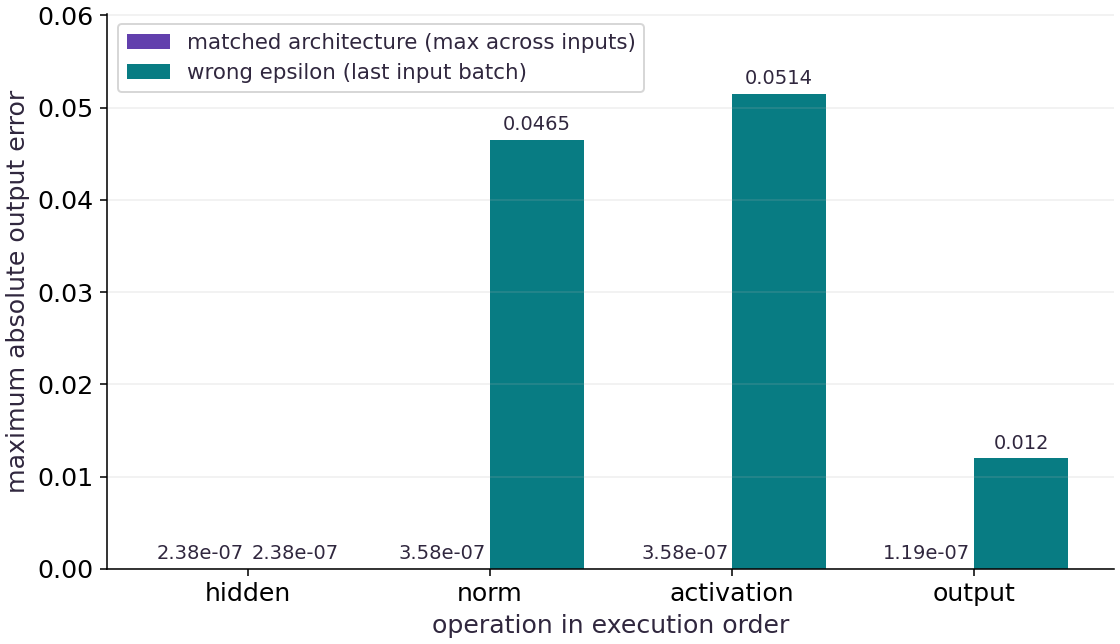

In [8]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

The horizontal categories follow execution order: hidden linear, normalization, activation and output. Bars show maximum absolute difference in that layer’s output units. The correct mapping remains near floating-point rounding error; the changed-epsilon model first diverges at normalization. The earlier matching hidden output narrows the cause. These are numerical errors, not accuracy or latency.

### Connect it to the computation

All weights are identical between the correct and wrong-epsilon target models. A parameter-file comparison alone would miss the changed operation. Later error may grow or shrink through nonlinearities and the output projection, so the largest bar is not necessarily the location of the original bug. The per-element tolerance and gradient checks are reported separately from this plot.

## Inspect the wrong-epsilon signature

Predict: Will the dense hidden output fail when only normalization epsilon changes?

In [9]:
# Experiment — Inspect the wrong-epsilon signature: Localize the first divergent operation before remapping...
# Assert invariant `wrong_reports['hidden']['passed']` holds
assert wrong_reports['hidden']['passed']
# Assert invariant `not wrong_reports['norm']['passed']` holds
assert not wrong_reports['norm']['passed']
# Print the observed values to compare against the expected result.
print('Per-layer wrong-epsilon report:',wrong_reports)

Per-layer wrong-epsilon report: {'hidden': {'max_abs': 2.384185791015625e-07, 'relative_l2': 3.5662515782829134e-08, 'passed': True}, 'norm': {'max_abs': 0.046508073806762695, 'relative_l2': 0.018277932316979384, 'passed': False}, 'activation': {'max_abs': 0.05144989490509033, 'relative_l2': 0.022399576976497533, 'passed': False}, 'output': {'max_abs': 0.011958837509155273, 'relative_l2': 0.013684121610437203, 'passed': False}}


Expected: The first dense layer passes; normalization fails first.

Localize the first divergent operation before remapping unrelated weights. The plot records downstream effects as well as the first failure.

## Test the tolerance rule near zero

Predict: Which differences pass at a zero reference and at a reference of $100$?

In [10]:
# Experiment — Test the tolerance rule near zero: The gate checks each element against a reference-dependent budget.
near_zero = error_report([0.], [1e-6])
# Run `error_report` to compute `near_zero_fail`.
near_zero_fail = error_report([0.], [3e-6])
# Run `error_report` to compute `large_value`.
large_value = error_report([100.], [100.001])
# Assert that `near_zero['passed'] and not near_zero_fail['passed'] and large_value['passed']`.
assert near_zero['passed'] and not near_zero_fail['passed'] and large_value['passed']
# Print the observed values to compare against the expected result.
print('Near-zero, excessive near-zero, large-value:', near_zero['passed'], near_zero_fail['passed'], large_value['passed'])

Near-zero, excessive near-zero, large-value: True False True


Expected: The three decisions are pass, fail, pass.

The gate checks each element against a reference-dependent budget. A single relative-error percentage is not a substitute.

## Your exercise

Compare a near-zero reference against two candidate errors. Verify that the absolute tolerance accepts rounding noise but rejects a meaningful discrepancy.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `error_report(...)` — Call `error_report` with your updated parameters or inputs from this lesson's workspace.
- `assert condition` — Verify that the observed output shape, status, or numerical value satisfies the contract.

**Step-by-step implementation plan:**
1. Assert invariant `error_report([0.` holds
2. Assert invariant `not error_report([0.` holds
3. Print the observed values to compare against the expected result.

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Compare a near-zero reference against two candidate errors.
# Assert invariant `error_report([0.` holds
assert error_report([0.,1.],[1e-7,1.000001])['passed']  # TODO: complete assertion check
# Assert invariant `not error_report([0.` holds
assert not error_report([0.,1.],[1e-3,1.])['passed']  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Near-zero acceptance and rejection verified.')
```

In [11]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Compare a near-zero reference against two candidate errors.
# Assert invariant `error_report([0.` holds
# assert error_report([0.,1.],[1e-7,1.000001])['passed']  # TODO: complete assertion check
# Assert invariant `not error_report([0.` holds
# assert not error_report([0.,1.],[1e-3,1.])['passed']  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Near-zero acceptance and rejection verified.')

## Reference solution

Try your own implementation first.

In [12]:
# Exercise solution: Compare a near-zero reference against two candidate errors.
# Assert invariant `error_report([0.` holds
assert error_report([0.,1.],[1e-7,1.000001])['passed']
# Assert invariant `not error_report([0.` holds
assert not error_report([0.,1.],[1e-3,1.])['passed']
# Print the observed values to compare against the expected result.
print('Near-zero acceptance and rejection verified.')

Near-zero acceptance and rejection verified.


## Reject a plausible but wrong tensor layout · Transfer

Transpose the first PyTorch weight before conversion and prove the boundary rejects it instead of transposing it a second time.

Hint: The first weight is rectangular, so validate its source shape before applying the mapping.

### How to write: Reject a plausible but wrong tensor layout — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `layout(...)` — Call `layout` with your updated parameters or inputs from this lesson's workspace.
- `convert(...)` — Call `convert` with your updated parameters or inputs from this lesson's workspace.

**Step-by-step implementation plan:**
1. Run the boundary check and catch the expected exception:

**Starter code scaffold (fill in the TODOs):**

```python
# Reject a plausible but wrong tensor layout (Transfer): Asymmetric dimensions expose orientation errors that square...
bad_state = dict(...)  # TODO: compute bad_state
bad_state['hidden.weight'] = ...  # TODO: compute bad_state['hidden.weight']
# Run the boundary check and catch the expected exception:
try:convert(bad_state)
except ValueError:print('Wrong source layout rejected')
else:raise AssertionError('layout mismatch accepted')
```

In [13]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Reject a plausible but wrong tensor layout (Transfer): Asymmetric dimensions expose orientation errors that square...
# bad_state = dict(...)  # TODO: compute bad_state
# bad_state['hidden.weight'] = ...  # TODO: compute bad_state['hidden.weight']
# Run the boundary check and catch the expected exception:
# try:convert(bad_state)
# except ValueError:print('Wrong source layout rejected')
# else:raise AssertionError('layout mismatch accepted')

## Reference reasoning

Asymmetric dimensions expose orientation errors that square test matrices can hide. Shape checks complement numerical checks rather than replacing them.

In [14]:
# Reject a plausible but wrong tensor layout (Transfer): Asymmetric dimensions expose orientation errors that square...
bad_state=dict(state)
bad_state['hidden.weight']=state['hidden.weight'].T
# Run the boundary check and catch the expected exception:
try:convert(bad_state)
except ValueError:print('Wrong source layout rejected')
else:raise AssertionError('layout mismatch accepted')

Wrong source layout rejected


## Check a nonuniform output sensitivity · Transfer / diagnosis

Compare the source and converted input gradients for an output cotangent that contains unequal positive and negative entries. Explain what this tests beyond summing the outputs.

Hint: Form the same scalar weighted output in each framework. Create a fresh PyTorch input so earlier gradients do not accumulate.

### How to write: Check a nonuniform output sensitivity — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).
- `jax.grad(loss_fn)(params, ...)` — Transforms a scalar-output function into a function returning the gradient PyTree with the same structure as `params`.

**Step-by-step implementation plan:**
1. Compute `probe_inputs` from `np.array([[.2, -.7, 1.1], [1., .4, -.5]], np.float32)`
2. Compute `cotangent` from `np.array([[1., -.5], [2., .25]], np.float32)`
3. Run `torch.tensor` to compute `probe_torch`.
4. Aggregate array values to compute `weighted_source`.
5. Run `weighted_source.backward` to perform the next check or state transition.

**Starter code scaffold (fill in the TODOs):**

```python
# Check a nonuniform output sensitivity (Transfer / diagnosis): This checks J^{\mathsf T}v for a second, nonuniform direction.
# Compute `probe_inputs` from `np.array([[.2, -.7, 1.1], [1., .4, -.5]], np.float32)`
probe_inputs = np.array(...)  # TODO: compute probe_inputs
# Compute `cotangent` from `np.array([[1., -.5], [2., .25]], np.float32)`
cotangent = np.array(...)  # TODO: compute cotangent
# Run `torch.tensor` to compute `probe_torch`.
probe_torch = torch.tensor(...)  # TODO: compute probe_torch
# Aggregate array values to compute `weighted_source`.
weighted_source = ...  # TODO: compute weighted_source
# Run `weighted_source.backward` to perform the next check or state transition.
weighted_source.backward()
# Differentiate the objective to obtain `weighted_target` via automatic differentiation.
weighted_target = jax.grad(...)  # TODO: compute weighted_target
# Run `error_report` to compute `vjp_report`.
vjp_report = error_report(...)  # TODO: compute vjp_report
# Assert invariant `vjp_report['passed']` holds
assert vjp_report['passed'], vjp_report  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
print('Nonuniform cotangent input-gradient parity:', vjp_report)
```

In [15]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Check a nonuniform output sensitivity (Transfer / diagnosis): This checks J^{\mathsf T}v for a second, nonuniform direction.
# Compute `probe_inputs` from `np.array([[.2, -.7, 1.1], [1., .4, -.5]], np.float32)`
# probe_inputs = np.array(...)  # TODO: compute probe_inputs
# Compute `cotangent` from `np.array([[1., -.5], [2., .25]], np.float32)`
# cotangent = np.array(...)  # TODO: compute cotangent
# Run `torch.tensor` to compute `probe_torch`.
# probe_torch = torch.tensor(...)  # TODO: compute probe_torch
# Aggregate array values to compute `weighted_source`.
# weighted_source = ...  # TODO: compute weighted_source
# Run `weighted_source.backward` to perform the next check or state transition.
# weighted_source.backward()
# Differentiate the objective to obtain `weighted_target` via automatic differentiation.
# weighted_target = jax.grad(...)  # TODO: compute weighted_target
# Run `error_report` to compute `vjp_report`.
# vjp_report = error_report(...)  # TODO: compute vjp_report
# Assert invariant `vjp_report['passed']` holds
# assert vjp_report['passed'], vjp_report  # TODO: complete assertion check
# Print the observed values to compare against the expected result.
# print('Nonuniform cotangent input-gradient parity:', vjp_report)

## Reference reasoning

This checks $J^{\mathsf T}v$ for a second, nonuniform direction. It can reveal errors hidden by an all-ones sensitivity. The same activation, normalization and parameter mapping must support both forward and derivative agreement.

In [16]:
# Check a nonuniform output sensitivity (Transfer / diagnosis): This checks J^{\mathsf T}v for a second, nonuniform direction.
# Compute `probe_inputs` from `np.array([[.2, -.7, 1.1], [1., .4, -.5]], np.float32)`
probe_inputs = np.array([[.2, -.7, 1.1], [1., .4, -.5]], np.float32)
# Compute `cotangent` from `np.array([[1., -.5], [2., .25]], np.float32)`
cotangent = np.array([[1., -.5], [2., .25]], np.float32)
# Run `torch.tensor` to compute `probe_torch`.
probe_torch = torch.tensor(probe_inputs, requires_grad=True)
# Aggregate array values to compute `weighted_source`.
weighted_source = (source(probe_torch)['output'] * torch.tensor(cotangent)).sum()
# Run `weighted_source.backward` to perform the next check or state transition.
weighted_source.backward()
# Differentiate the objective to obtain `weighted_target` via automatic differentiation.
weighted_target = jax.grad(lambda z: jnp.sum(target(z)['output'] * jnp.asarray(cotangent)))(jnp.asarray(probe_inputs))
# Run `error_report` to compute `vjp_report`.
vjp_report = error_report(probe_torch.grad.numpy(), weighted_target, atol=5e-6, rtol=5e-5)
# Assert invariant `vjp_report['passed']` holds
assert vjp_report['passed'], vjp_report
# Print the observed values to compare against the expected result.
print('Nonuniform cotangent input-gradient parity:', vjp_report)

Nonuniform cotangent input-gradient parity: {'max_abs': 2.086162567138672e-07, 'relative_l2': 4.910744924550249e-07, 'passed': True}


## Checkpoint

The first linear layer agrees, but LayerNorm is the first mismatch. What should you inspect next?

1. Normalization axes, variance calculation, epsilon and affine parameters.
2. Relax every tolerance until the final outputs pass.
3. Assume successful checkpoint loading proves parity.

## Diagnose

Reject missing, extra, malformed or nonfinite weights before assignment. If the first linear output differs, inspect orientation and bias. If normalization first differs, inspect its contract. If forward outputs agree but gradients differ, inspect operation approximations and differentiability; retain both results.

## Evidence

Keep source checkpoint and architecture identity, complete parameter mapping, per-layer max-absolute/relative-L2 errors, elementwise tolerances, input-gradient comparisons, wrong-epsilon diagnosis and a fresh-process converted-artifact receipt.

## Primary references

- [PyTorch state_dict and weights-only loading](https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html)
- [Flax NNX Linear](https://flax.readthedocs.io/en/latest/api_reference/flax.nnx/nn/linear.html)